# RZR Analytics Challenge - Statistical Analysis (Python)
Associate Analyst, PH - Case Study

John Carlo M. Borromeo

This notebook is the step after cleaning the data in Excel and running the first pass of exploration in SQL. What Excel and SQL can't easily tell you is whether a pattern you're looking at is real or just random noise. That's what this notebook is for.

Every time this notebook says a segment "matters" or "drives lead quality," it's backed by a statistical test, not just a bigger or smaller percentage on a chart. A percentage difference on its own can be misleading, especially when the group sizes are small. The tests here are what separate a real pattern from a coincidence.

Input file: leads_clean.csv (the same cleaned dataset used in the SQL step, 3,021 leads, April to September 2009)


## 1. Setup and loading the data

In [25]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

df = pd.read_csv('leads_clean.csv', parse_dates=['lead_created', 'lead_created_date'])
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head(3)


Loaded 3,021 rows, 32 columns


,lead_created,first_name,email,vendor_lead_id,call_status,widget_name,publisher_zone_name,publisher_campaign_name,address_score,phone_score,advertiser_campaign_name,state,debt_level_raw,partner,referral_domain,marketing_campaign,ad_group,keyword,search_query,referral_url,referral_url_params,landing_page_url,landing_page_url_params,is_duplicate_lead_id,lead_quality_bucket,is_closed,debt_level_low,debt_level_high,debt_level_midpoint,lead_created_date,lead_created_month,lead_created_week
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,(Blank),w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,creditsolutions-branded-shortform,HI,30001-50000,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...,0,Unknown - No Outcome Recorded,0,30001,50000.0,40000.5,2009-07-01,2009-07,2009-06-29/2009-07-05
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,(Blank),w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,AL,90000-100000,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,0,Unknown - No Outcome Recorded,0,90000,100000.0,95000.0,2009-04-13,2009-04,2009-04-13/2009-04-19
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,NY,20001-30000,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,0,Bad,0,20001,30000.0,25000.5,2009-04-21,2009-04,2009-04-20/2009-04-26


`is_closed` is the number we care about most in this notebook. It's 1 if `call_status` is exactly "Closed," and 0 otherwise. This matches how "lead quality" is defined in the case brief: closed leads divided by all leads sold, not just the leads that already have a final outcome recorded.

In [26]:
# Checking if this matches the 8.0% baseline mentioned in the brief
total = len(df)
closed = df['is_closed'].sum()
baseline_rate = closed / total * 100
print(f"Total leads: {total:,}")
print(f"Closed leads: {closed}")
print(f"Baseline quality rate: {baseline_rate:.2f}%  <- matches the advertiser's stated 8.0%")


Total leads: 3,021
Closed leads: 245
Baseline quality rate: 8.11%  <- matches the advertiser's stated 8.0%


---
## 2. Question 1: Are we seeing lead quality trends over time? Are they statistically significant?

### Why a chi-square test
The question we're really asking is: does the month a lead came in have anything to do with whether it closed or not? Both of those things (month, and closed or not) are categories, not numbers, so a chi-square test of independence is the right tool. It compares what we actually saw against what we'd expect to see if month and closing had nothing to do with each other, and tells us how likely it is that the difference is just random luck.

### Why month, and not day
The dataset covers about 182 days, but only 3,021 leads total. That works out to roughly 16 to 17 leads a day, and since the average close rate is only about 8%, most days only have 0 to 3 closed leads. A day going from 0% to 25% close rate isn't a signal, it's just what happens when you're dividing by a very small number. I checked, and 53 of the 182 days (29%) had zero closed leads at all. Grouping by month gives each bucket 438 to 609 leads, which is enough for the percentages and the test to actually mean something.

In [27]:
monthly = df.groupby('lead_created_month').agg(
    total_leads=('is_closed', 'size'),
    closed_leads=('is_closed', 'sum')
)
monthly['quality_rate_pct'] = (monthly['closed_leads'] / monthly['total_leads'] * 100).round(2)
monthly


,total_leads,closed_leads,quality_rate_pct
lead_created_month,,,
2009-04,518,56,10.81
2009-05,580,37,6.38
2009-06,609,63,10.34
2009-07,532,33,6.20
2009-08,438,41,9.36
2009-09,344,15,4.36


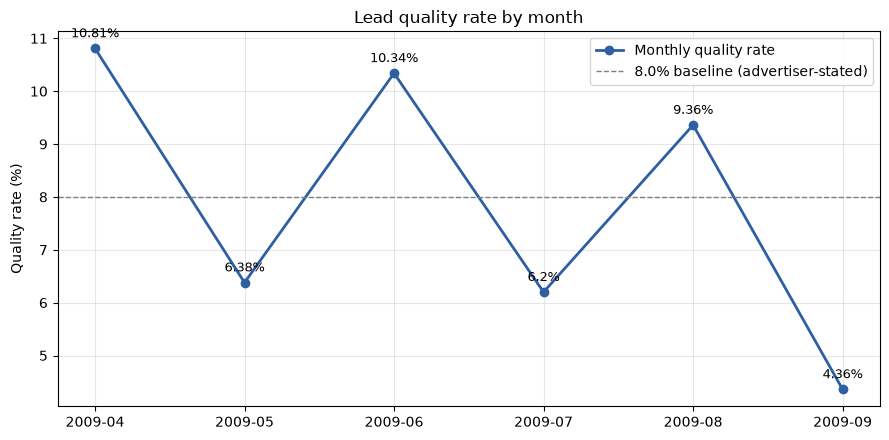

In [28]:
fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(monthly.index, monthly['quality_rate_pct'], marker='o', linewidth=2, color='#2E5FA3', label='Monthly quality rate')
ax.axhline(8.0, color='gray', linestyle='--', linewidth=1, label='8.0% baseline (advertiser-stated)')
ax.set_ylabel('Quality rate (%)')
ax.set_title('Lead quality rate by month')
ax.legend()
for x, y in zip(monthly.index, monthly['quality_rate_pct']):
    ax.annotate(f'{y}%', (x,y), textcoords="offset points", xytext=(0,8), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


In [29]:
# Chi-square test: is there a real association between month and closed/not-closed?
contingency = pd.crosstab(df['lead_created_month'], df['is_closed'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.4f}")
print(f"Smallest expected count in any cell: {expected.min():.1f}  (should be 5 or more for the test to be reliable)")
print()
if p_value < 0.05:
    print("Result: SIGNIFICANT (p < 0.05). The month to month difference is unlikely to be random noise.")
else:
    print("Result: NOT significant (p >= 0.05). Could plausibly be random noise.")


Chi-square statistic: 21.4884
Degrees of freedom:   5
p-value:              0.0007
Smallest expected count in any cell: 27.9  (should be 5 or more for the test to be reliable)

Result: SIGNIFICANT (p < 0.05). The month to month difference is unlikely to be random noise.


**What this means:** the p-value is 0.0007, well under the usual 0.05 cutoff, and every cell has plenty of expected leads in it, so this is a test we can trust. There's a real month to month effect here.

But "real" doesn't mean "smooth decline." Look at the chart again: it goes 10.8%, 6.4%, 10.3%, 6.2%, 9.4%, then drops to 4.4% in September. That's a zigzag, not a straight line down. September stands out as the worst month by a clear margin, and that's worth a follow up on what changed operationally around then, rather than just concluding that the "quality is declining."

### Adding a weekly view
Monthly is the right level for the significance test, but it smooths a lot of detail away. Here, I broke it down by week too, just to see the shape of things more closely. I'll test significance at this level as well, but treat the monthly result as the one to actually rely on, for reasons explained after the chart.

In [30]:
weekly = df.groupby('lead_created_week').agg(
    total_leads=('is_closed', 'size'),
    closed_leads=('is_closed', 'sum')
)
weekly['quality_rate_pct'] = (weekly['closed_leads'] / weekly['total_leads'] * 100).round(2)
weekly


,total_leads,closed_leads,quality_rate_pct
lead_created_week,,,
2009-03-30/2009-04-05,37,3,8.11
2009-04-06/2009-04-12,119,15,12.61
2009-04-13/2009-04-19,125,16,12.80
2009-04-20/2009-04-26,155,14,9.03
2009-04-27/2009-05-03,129,10,7.75
2009-05-04/2009-05-10,113,10,8.85
2009-05-11/2009-05-17,166,12,7.23
2009-05-18/2009-05-24,122,8,6.56
2009-05-25/2009-05-31,132,5,3.79


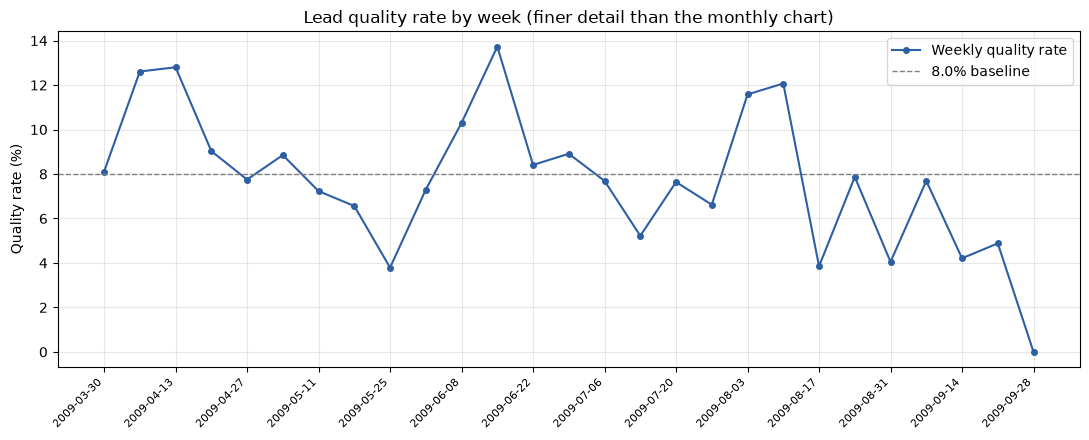

In [31]:
fig, ax = plt.subplots(figsize=(11,4.5))
x = range(len(weekly))
ax.plot(x, weekly['quality_rate_pct'], marker='o', linewidth=1.5, markersize=4, color='#2E5FA3', label='Weekly quality rate')
ax.axhline(8.0, color='gray', linestyle='--', linewidth=1, label='8.0% baseline')
ax.set_ylabel('Quality rate (%)')
ax.set_title('Lead quality rate by week (finer detail than the monthly chart)')
ax.set_xticks(list(x)[::2])
ax.set_xticklabels([weekly.index[i][:10] for i in x[::2]], rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()


In [32]:
# Chi-square test at the weekly level
weekly_ct = pd.crosstab(df['lead_created_week'], df['is_closed'])
chi2_w, p_w, dof_w, expected_w = stats.chi2_contingency(weekly_ct)

print(f"Chi-square statistic: {chi2_w:.4f}")
print(f"Degrees of freedom:   {dof_w}")
print(f"p-value:              {p_w:.4f}")
print(f"Smallest expected count in any cell: {expected_w.min():.2f}  (below 5 means the test is on shakier ground)")


Chi-square statistic: 35.4725
Degrees of freedom:   26
p-value:              0.1018
Smallest expected count in any cell: 3.00  (below 5 means the test is on shakier ground)


**What this means:** at the weekly level the p-value comes out to about 0.10, which is not significant. That might seem to contradict the monthly result, but it doesn't really. Cutting the data into 27 weekly buckets instead of 6 monthly ones means each bucket has fewer leads, some cells drop below the usual rule of thumb of 5 expected leads per cell, and the test needs stronger evidence to call anything significant when there are more groups to compare.

So here's how the two can be used: the monthly result is what can be cited when someone asks "is this significant," because that test has clean and well sized buckets. The weekly chart is there to look at, not to test. And it does show something the monthly chart hides: the week of September 28 to October 4 had zero closed leads out of 41. The monthly average for September (4.4%) blends that dead week in with better ones earlier in the month.

---
## 3. Question 2: What drives lead quality? Which segments actually matter?

### Why a chi-square test again
Same logic as before. We're comparing a category (which ad, which state, which debt bracket, and so on) against a category (closed or not). Chi-square tells us, for each of these, whether the differences in close rate between groups are bigger than what random chance alone would produce.

### Why we filter out tiny groups first
If a segment only has 8 or 10 leads in it, one extra closed lead can swing the percentage by several points. That's just noise from a small sample and not a real pattern. So before testing anything, I'll drop any group with fewer than 20 leads. This keeps the test honest and stops a rare, small, and lucky group from getting mistaken for a real driver.

In [33]:
candidate_drivers = {
    'debt_level_raw': 'Debt Level',
    'phone_score': 'Phone Score',
    'publisher_campaign_name': 'Intake Channel (Call Center vs. Online Form)',
    'publisher_zone_name': 'Page Placement',
    'advertiser_campaign_name': 'Ad Branding (branded vs. generic)',
    'state': 'State',
    'address_score': 'Address Score',
}

results = []
for col, label in candidate_drivers.items():
    sub = df.dropna(subset=[col])
    ct = pd.crosstab(sub[col], sub['is_closed'])
    ct = ct[ct.sum(axis=1) >= 20]   # drop groups with fewer than 20 leads, too small to trust
    if ct.shape[0] < 2:
        continue
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    results.append({'driver': label, 'p_value': round(p, 4), 'n_groups_tested': ct.shape[0], 'n_leads': int(sub.shape[0])})

results_df = pd.DataFrame(results).sort_values('p_value')
results_df['significant_at_0.05'] = results_df['p_value'] < 0.05
results_df


,driver,p_value,n_groups_tested,n_leads,significant_at_0.05
0,Debt Level,0.0062,10,3021,True
1,Phone Score,0.0524,4,1393,False
6,Address Score,0.3224,5,1171,False
2,Intake Channel (Call Center vs. Online Form),0.4114,2,3021,False
3,Page Placement,0.4114,2,3021,False
4,Ad Branding (branded vs. generic),0.6528,2,3021,False
5,State,0.7358,27,3021,False


**Special case: Ad Creative (widget_name).** This one gets its own cell because on a raw percentage basis, it looks like the strongest driver in the whole dataset, some designs close at 15.6% and others at 5.3%. That's exactly the kind of chart that ends up being mitakenly included in a dashboard  without anyone checking whether it's real. Same test and the 20-lead minimum are applied here too, for consistency with every other driver we just tested.

In [34]:
widget_ct = pd.crosstab(df['widget_name'], df['is_closed'])
widget_ct = widget_ct[widget_ct.sum(axis=1) >= 20]

chi2_wd, p_wd, dof_wd, expected_wd = stats.chi2_contingency(widget_ct)
print(f"Ad Creative (Widget) chi-square test: p-value = {p_wd:.4f}, groups tested = {widget_ct.shape[0]}")
print("Result: NOT significant" if p_wd >= 0.05 else "Result: SIGNIFICANT")

widget_summary = df.groupby('widget_name').agg(n=('is_closed','size'), closed=('is_closed','sum'))
widget_summary['quality_rate_pct'] = (widget_summary['closed']/widget_summary['n']*100).round(2)
widget_summary = widget_summary[widget_summary['n']>=20].sort_values('quality_rate_pct', ascending=False)
widget_summary


Ad Creative (Widget) chi-square test: p-value = 0.1311, groups tested = 13
Result: NOT significant


,n,closed,quality_rate_pct
widget_name,,,
w-300250-DebtReduction1-1DC-CreditSolutions,77,12,15.58
w-300250-DebtReduction1-1DC-BlueMeter,92,13,14.13
w-300250-DebtReduction1-1DC-Head2,89,11,12.36
w-300250-DebtReduction1-1DC,348,34,9.77
w-302252-DebtReduction1-1DC,272,23,8.46
w-300250-DebtReduction1-2DC-CreditSolutions,75,6,8.00
w-302252-DebtReduction1-1DC-yellowarrow-dark,135,10,7.41
w-302252-DebtReduction1-1DC-white,430,31,7.21
w-302252-DebtReduction1-1DC-CreditSolutions,1054,76,7.21


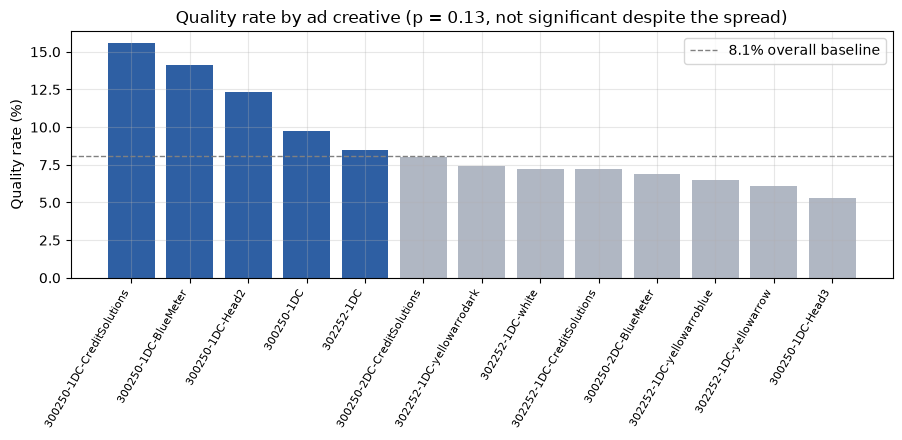

In [35]:
fig, ax = plt.subplots(figsize=(9,4.5))
colors = ['#2E5FA3' if r>=8.11 else '#B0B7C3' for r in widget_summary['quality_rate_pct']]
ax.bar(range(len(widget_summary)), widget_summary['quality_rate_pct'], color=colors)
ax.axhline(baseline_rate, color='gray', linestyle='--', linewidth=1, label=f'{baseline_rate:.1f}% overall baseline')
ax.set_xticks(range(len(widget_summary)))
ax.set_xticklabels([w.replace('w-','').replace('DebtReduction1-','') for w in widget_summary.index], rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Quality rate (%)')
ax.set_title(f'Quality rate by ad creative (p = {p_wd:.2f}, not significant despite the spread)')
ax.legend()
plt.tight_layout()
plt.show()


**What this means, and this is the main finding of the whole analysis:**

| Driver | p-value | Real? |
|---|---|---|
| Debt Level | 0.0062 | Yes |
| Phone Score | 0.0524 | Borderline, right on the edge |
| Intake Channel, Page Placement, Ad Branding, State, Address Score | 0.32 to 0.74 | No |
| Ad Creative | 0.13 | No, even though it looked the most dramatic |

Only Debt Level holds up as a real and validated driver of lead quality. Everything else, including Ad Creative which had the biggest visual spread of any chart in this notebook, is consistent with random noise once you account for how many leads are actually behind each bar. This is the one thing worth emphasizing: it is not recommended to change the ad creative based on this data, even though the raw numbers make it tempting to.

In [36]:
order = ['7500-10000','7500-15000','10001-15000','15001-20000','20001-30000',
         '30001-50000','50001-70000','70001-90000','90000-100000','More_than_100000']

debt_summary = df.groupby('debt_level_raw').agg(n=('is_closed','size'), closed=('is_closed','sum'))
debt_summary['quality_rate_pct'] = (debt_summary['closed']/debt_summary['n']*100).round(2)
debt_summary = debt_summary.reindex(order)
debt_summary


,n,closed,quality_rate_pct
debt_level_raw,,,
7500-10000,442,22,4.98
7500-15000,271,19,7.01
10001-15000,291,34,11.68
15001-20000,408,35,8.58
20001-30000,456,40,8.77
30001-50000,496,39,7.86
50001-70000,245,22,8.98
70001-90000,131,18,13.74
90000-100000,90,9,10.00


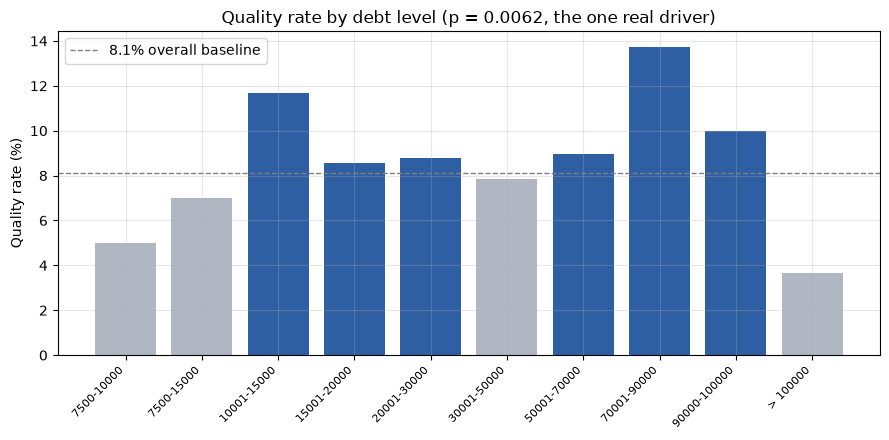

In [37]:
fig, ax = plt.subplots(figsize=(9,4.5))
colors = ['#2E5FA3' if r>=8.11 else '#B0B7C3' for r in debt_summary['quality_rate_pct']]
ax.bar(range(len(debt_summary)), debt_summary['quality_rate_pct'], color=colors)
ax.axhline(baseline_rate, color='gray', linestyle='--', linewidth=1, label=f'{baseline_rate:.1f}% overall baseline')
ax.set_xticks(range(len(debt_summary)))
ax.set_xticklabels([d.replace('_',' ').replace('More than','>') for d in debt_summary.index], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Quality rate (%)')
ax.set_title('Quality rate by debt level (p = 0.0062, the one real driver)')
ax.legend()
plt.tight_layout()
plt.show()


The pattern isn't a straight line. Quality is highest in the $10K  to  $15K and $70K to $90K ranges (11.7% and 13.7%), and lowest at both ends, very low debt ($7.5K to $10K, 5.0%) and very high debt (over $100K, only 3.7%). The high debt result makes sense from a business angle too. Someone carrying over $100K in debt may just be too far along to realistically qualify for a debt settlement program, so they were never likely to close in the first place.

---
## 4. Question 3: Can we hit 9.6% quality for a 20% CPL increase ($30 to $33)?

We only have one driver that passed the significance test, Debt Level, so both scenarios below are built on that. Two ways to use it are compared: cutting out the worst leads versus shifting more ad spend toward the debt levels that already perform well. No new statistical test is needed here since we're just applying the Debt Level finding from Question 2, but the reasoning behind each number is written out below.

In [38]:
CPL_CURRENT = 30
CPL_NEW = 33
TARGET_RATE = 9.6

current_revenue = total * CPL_CURRENT
print(f"Baseline: {total:,} leads x ${CPL_CURRENT} = ${current_revenue:,}")
print(f"Baseline quality rate: {baseline_rate:.2f}%  |  Target: {TARGET_RATE}%")


Baseline: 3,021 leads x $30 = $90,630
Baseline quality rate: 8.11%  |  Target: 9.6%


In [39]:
# Strategy A: filter out the worst debt and phone-score segments
exclude_debt = df['debt_level_raw'].isin(['More_than_100000', '7500-10000'])
exclude_phone = df['phone_score'].isin([2, 4])   # only affects leads where phone_score is known

filtered = df[~(exclude_debt | exclude_phone)]
filtered_rate = filtered['is_closed'].sum() / len(filtered) * 100
filtered_revenue = len(filtered) * CPL_NEW

print("Strategy A: filter out the worst performing leads")
print(f"  Leads remaining: {len(filtered):,} (dropped {total - len(filtered):,}, {(total-len(filtered))/total*100:.1f}% of volume)")
print(f"  New quality rate: {filtered_rate:.2f}%")
print(f"  Revenue: {len(filtered):,} x ${CPL_NEW} = ${filtered_revenue:,}  ({(filtered_revenue/current_revenue-1)*100:+.1f}% vs. baseline)")


Strategy A: filter out the worst performing leads
  Leads remaining: 2,133 (dropped 888, 29.4% of volume)
  New quality rate: 9.61%
  Revenue: 2,133 x $33 = $70,389  (-22.3% vs. baseline)


In [40]:
# Strategy B: shift volume toward better performing debt segments, keep total volume the same
g = df.groupby('debt_level_raw').agg(n=('is_closed','size'), closed=('is_closed','sum')).astype(float)
g['rate'] = g['closed'] / g['n']
total_n = g['n'].sum()

worst_segments = ['More_than_100000', '7500-10000']
best_segments  = ['70001-90000', '10001-15000']

def simulate_reallocation(shift_pct):
    # Moves shift_pct of TOTAL volume out of the worst segments and into the best ones,
    # spread proportionally within each group. Assumes each segment's own close rate
    # stays the same as its volume changes, which is a simplification, explained below.
    shift_amount = total_n * shift_pct
    worst_n = g.loc[worst_segments, 'n'].sum()
    best_n = g.loc[best_segments, 'n'].sum()
    if shift_amount > worst_n:
        return None
    new_g = g.copy()
    for seg in worst_segments:
        new_g.loc[seg, 'n'] -= shift_amount * (g.loc[seg, 'n'] / worst_n)
    for seg in best_segments:
        new_g.loc[seg, 'n'] += shift_amount * (g.loc[seg, 'n'] / best_n)
    new_g['closed'] = new_g['n'] * g['rate']
    return new_g['closed'].sum() / new_g['n'].sum() * 100, new_g['n'].sum()

print(f"{'Shift %':>8} | {'New quality rate':>18} | {'Total leads':>12}")
for pct in [0, 0.05, 0.10, 0.15, 0.20]:
    rate, n = simulate_reallocation(pct)
    print(f"{pct*100:>7.0f}% | {rate:>17.2f}% | {n:>12.0f}")


 Shift % |   New quality rate |  Total leads
      0% |              8.11% |         3021
      5% |              8.50% |         3021
     10% |              8.88% |         3021
     15% |              9.27% |         3021
     20% |              9.66% |         3021


In [41]:
reallocation_rate, reallocation_n = simulate_reallocation(0.20)
reallocation_revenue = total * CPL_NEW

print("Strategy B: shift ad spend toward better debt segments, same total volume")
print(f"  Total leads: {total:,} (unchanged)")
print(f"  New quality rate: {reallocation_rate:.2f}%")
print(f"  Revenue: {total:,} x ${CPL_NEW} = ${reallocation_revenue:,}  ({(reallocation_revenue/current_revenue-1)*100:+.1f}% vs. baseline)")


Strategy B: shift ad spend toward better debt segments, same total volume
  Total leads: 3,021 (unchanged)
  New quality rate: 9.66%
  Revenue: 3,021 x $33 = $99,693  (+10.0% vs. baseline)


In [42]:
comparison = pd.DataFrame([
    {'Strategy': 'Current baseline', 'Leads': total, 'Quality Rate %': round(baseline_rate,2), 'CPL': CPL_CURRENT, 'Revenue': current_revenue},
    {'Strategy': 'A: Filter out worst leads', 'Leads': len(filtered), 'Quality Rate %': round(filtered_rate,2), 'CPL': CPL_NEW, 'Revenue': filtered_revenue},
    {'Strategy': 'B: Reallocate spend, same volume', 'Leads': int(reallocation_n), 'Quality Rate %': round(reallocation_rate,2), 'CPL': CPL_NEW, 'Revenue': reallocation_revenue},
])
comparison['Revenue vs. Baseline'] = (comparison['Revenue']/current_revenue - 1).apply(lambda x: f"{x*100:+.1f}%")
comparison


,Strategy,Leads,Quality Rate %,CPL,Revenue,Revenue vs. Baseline
0,Current baseline,3021,8.11,30,90630,+0.0%
1,A: Filter out worst leads,2133,9.61,33,70389,-22.3%
2,"B: Reallocate spend, same volume",3020,9.66,33,99693,+10.0%


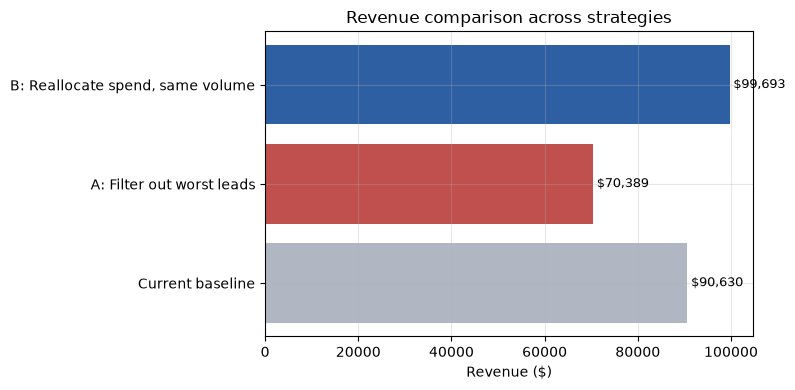

In [43]:
fig, ax = plt.subplots(figsize=(8,4))
strategies = comparison['Strategy']
revenues = comparison['Revenue']
colors = ['#B0B7C3', '#C0504D', '#2E5FA3']
ax.barh(strategies, revenues, color=colors)
for i, v in enumerate(revenues):
    ax.text(v+800, i, f"\${v:,.0f}", va='center', fontsize=9)
ax.set_xlabel('Revenue ($)')
ax.set_title('Revenue comparison across strategies')
plt.tight_layout()
plt.show()


**What this means:** both strategies technically reach the 9.6% target. But Strategy A gets there by throwing away 29% of the leads, so even with the higher $33 CPL, revenue drops 22%. Strategy B reaches an even higher 9.66% by shifting spend toward the debt levels that already convert well, without shrinking total volume, so revenue actually goes up 10%.

The reallocation approach is the one worth recommending: shift media spend toward the $10K to $15K and $70K to $90K debt profiles, and away from over $100K debt, rather than filtering leads after they've already been bought.

Here are a few things to keep in mind for this recommendation:
1. Strategy B assumes each debt segment keeps converting at its current rate even as more volume flows into it. In reality, pulling three times more traffic into a segment that currently converts well might not hold that rate steady, there could be diminishing returns. As such, 9.66% should be treated as an optimistic estimate and not a guarantee.
2. The segments excluded in Strategy A were picked specifically to hit the 9.6% number. This was only done to show that it is mathematically possible but, in reality, this step isn't a validated recommendation.
3. Phone Score, used in Strategy A, is only available for 46% of leads. Any recommendation built on it is weaker than one built on Debt Level, which is filled in for every single lead.


---
## 5. Summary

| Question | Answer |
|---|---|
| Q1: Trend over time? | Yes, statistically significant at the monthly level (p = 0.0007), but it's a zigzag, not a steady decline. September stands out as the worst month and deserves a closer look at what happened operationally. |
| Q2: What drives quality? | Only Debt Level holds up as a real driver (p = 0.0062). Ad Creative looks like the strongest driver on a raw percentage basis but fails the significance test (p = 0.13), a good reminder not to trust a bar chart without checking the sample sizes behind it. Phone Score is right on the edge (p = 0.052). |
| Q3: Path to 9.6%? | Reachable, but how you get there matters. Shifting ad spend toward better converting debt segments gets to 9.66% and grows revenue by 10%. Filtering out bad leads after the fact also hits the target number, but shrinks revenue by 22% because it throws away too much volume to be worth it. |
